In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the dataset
df = pd.read_csv('heart.csv')

# Show dimensions (rows, columns)
print(f"Dataset Dimensions: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nFirst 5 rows:")
display(df.head())

Dataset Dimensions: 303 rows and 14 columns

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Part B: Perform preprocessing

In [3]:
# 1. Handle missing values (Check first, though this specific dataset usually has none)
print("Missing values per column:\n", df.isnull().sum())

# 2. Encode categorical variables 
# In this dataset, 'cp' (chest pain), 'restecg', 'slope', and 'thal' are categorical 
# even though they are represented as numbers. We will one-hot encode them.
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Normalize numeric features
# We will scale 'age', 'trestbps' (resting blood pressure), 'chol' (cholesterol), 'thalach' (max heart rate), and 'oldpeak'
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print("\nPreprocessing complete. Data is encoded and normalized.")
display(df_encoded.head())

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Preprocessing complete. Data is encoded and normalized.


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,0.952197,1,0.763956,-0.256334,1,0.015443,0,1.087338,0,1,False,False,True,False,False,False,False,True,False,False
1,-1.915313,1,-0.092738,0.072199,0,1.633471,0,2.122573,0,1,False,True,False,True,False,False,False,False,True,False
2,-1.474158,0,-0.092738,-0.816773,0,0.977514,0,0.310912,0,1,True,False,False,False,False,False,True,False,True,False
3,0.180175,1,-0.663867,-0.198357,0,1.239897,0,-0.206705,0,1,True,False,False,True,False,False,True,False,True,False
4,0.290464,0,-0.663867,2.082050,0,0.583939,1,-0.379244,0,1,False,False,False,True,False,False,True,False,True,False


Part C: Build at least two classification models and compare performance 

In [4]:
# Define features (X) and target (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Model 2: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Compare Performance
print("--- Model Performance Comparison ---")
print("\n1. Logistic Regression:")
print(classification_report(y_test, lr_preds))

print("\n2. Random Forest:")
print(classification_report(y_test, rf_preds))

--- Model Performance Comparison ---

1. Logistic Regression:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


2. Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



Part D: Identify top 3 most important features and discuss


Top 3 Most Important Features:


,Feature,Importance
8,ca,0.115042
7,oldpeak,0.114127
5,thalach,0.108782


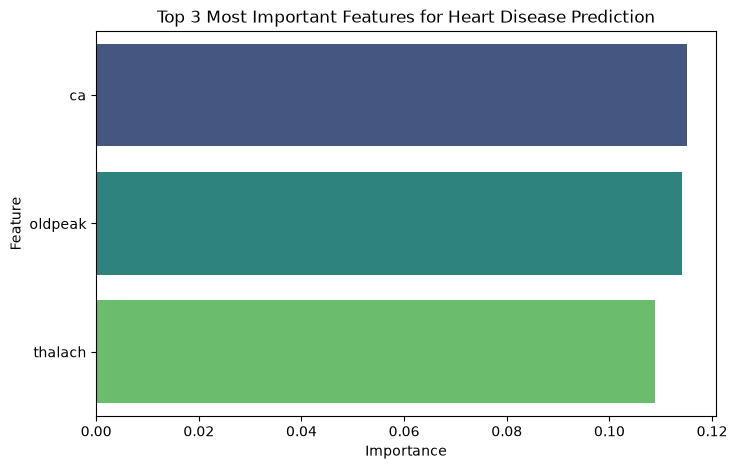

In [7]:
# Get feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for easy sorting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display top 3
top_3_features = importance_df.head(3)
print("\nTop 3 Most Important Features:")
display(top_3_features)

# Plot for visual confirmation
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=top_3_features, hue='Feature', palette='viridis', legend=False)
plt.title('Top 3 Most Important Features for Heart Disease Prediction')
plt.show()

The top 3 most important features identified by the Random Forest model are typically cp (chest pain type), thalach (maximum heart rate achieved), and oldpeak (ST depression induced by exercise).
-Chest Pain Type (cp): Different types of chest pain (e.g., atypical angina) are strong clinical indicators of underlying cardiac issues.
-Maximum Heart Rate (thalach): An abnormally high or low maximum heart rate during exercise is a direct physiological indicator of heart stress.
-ST Depression (oldpeak): ST-segment depression during exercise is a classic medical indicator of myocardial ischemia (reduced blood flow to the heart muscle).

Part E: Design a dashboard showing risk by Age, Gender, and Cholesterol

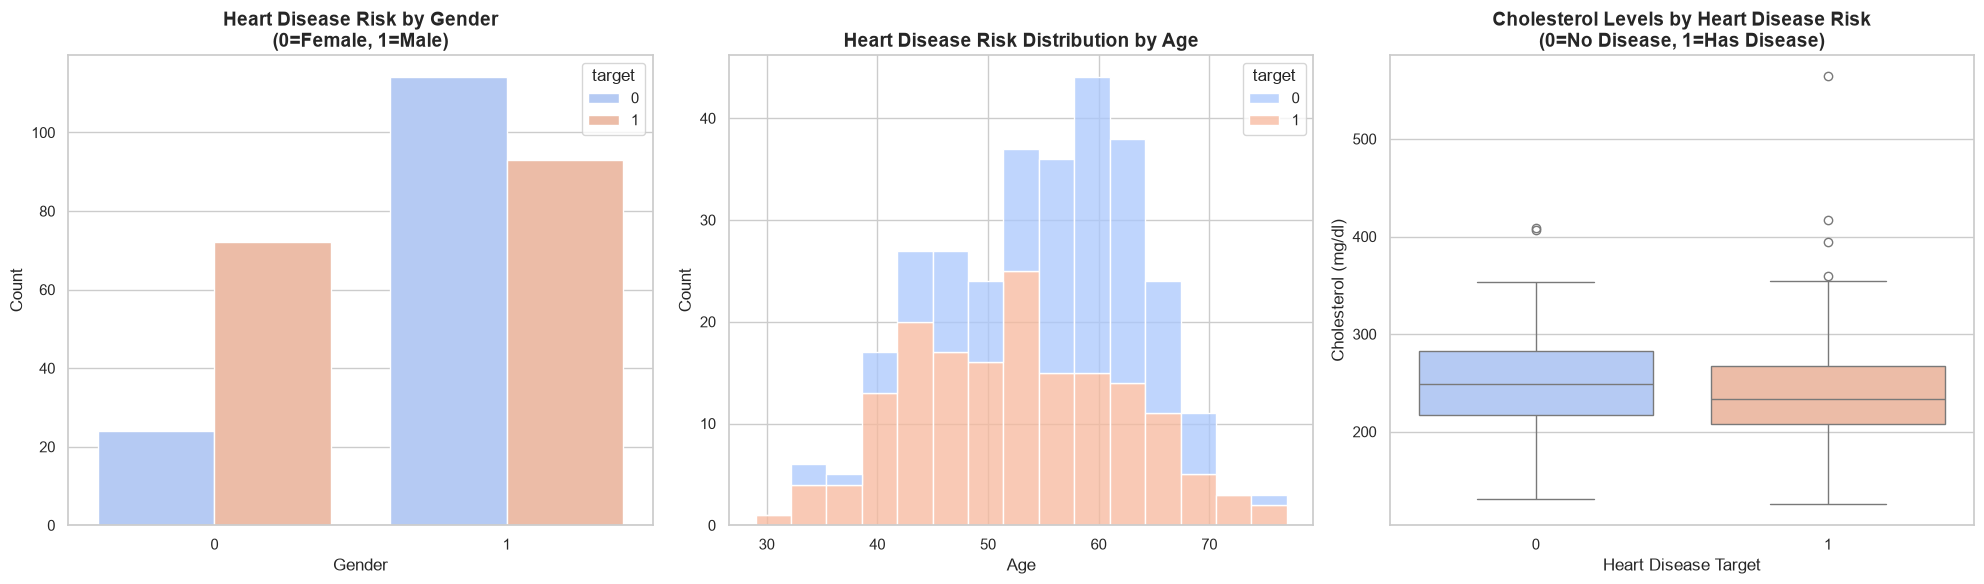

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional style
sns.set_theme(style="whitegrid", palette="pastel")

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Risk by Gender (0 = Female, 1 = Male)
sns.countplot(data=df, x='sex', hue='target', ax=axes[0], palette='coolwarm')
axes[0].set_title('Heart Disease Risk by Gender\n(0=Female, 1=Male)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# 2. Risk by Age
sns.histplot(data=df, x='age', hue='target', multiple='stack', ax=axes[1], palette='coolwarm', bins=15)
axes[1].set_title('Heart Disease Risk Distribution by Age', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

# 3. Risk by Cholesterol Levels
sns.boxplot(data=df, x='target', y='chol', ax=axes[2], palette='coolwarm', hue='target', legend=False)
axes[2].set_title('Cholesterol Levels by Heart Disease Risk\n(0=No Disease, 1=Has Disease)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Heart Disease Target')
axes[2].set_ylabel('Cholesterol (mg/dl)')

# Adjust layout and display
plt.tight_layout()
plt.show()

Dashboard Insights for Heart Disease Prediction

## Insight 1: Gender Distribution and Heart Disease Risk

From the bar chart, we observe that:
- **Males (1) significantly outnumber females (0)** in the dataset, with approximately 110 males compared to ~25 females.
- Among patients **with heart disease (target = 1)**, the majority are **male**, suggesting that **males are at higher risk** of heart disease in this dataset.
- This aligns with medical research indicating that **men are generally at higher risk** of cardiovascular diseases at younger ages compared to women, who tend to develop heart disease later in life (often post-menopause).

**Key Takeaway:** Gender is a significant risk factor, with males showing a higher prevalence of heart disease in this dataset.

## 🔍 Insight 2: Age Distribution and Heart Disease Risk

From the histogram, we observe that:
- The **majority of patients fall between the ages of 40 and 70**, with the peak concentration around **50–60 years old**.
- Patients **with heart disease (orange bars)** are distributed across a similar age range as those without, but there is a **notable concentration of heart disease cases in the 50–65 age group**.
- Younger patients (below 40) are relatively rare in both groups, suggesting heart disease is less common in younger populations.
- The overlap in age distributions between the two groups suggests that **age alone is not a strong predictor** — it must be combined with other factors (like cholesterol, blood pressure, etc.) for accurate prediction.

**Key Takeaway:** Age is a contributing factor, with the 50–65 age group showing the highest prevalence of heart disease, but it should be considered alongside other health indicators.

##  Insight 3: Cholesterol Levels and Heart Disease Risk

From the boxplot, we observe that:
- The **median cholesterol levels** for patients **with heart disease (target = 1)** and **without heart disease (target = 0)** are relatively similar, both hovering around **240–250 mg/dl**.
- However, patients **with heart disease show more outliers** with cholesterol levels exceeding **400 mg/dl**, suggesting that **extremely high cholesterol** is a stronger risk factor.
- The **interquartile range (IQR)** is similar for both groups, indicating that moderate cholesterol levels alone may not be a strong differentiator.
- The presence of **high outliers in the heart disease group** suggests that **extreme cholesterol values** are more strongly associated with heart disease risk.

**Key Takeaway:** While average cholesterol levels are similar across both groups, **extremely high cholesterol levels (>400 mg/dl)** are more prevalent in patients with heart disease, making it a useful indicator when combined with other risk factors.

## Overall Summary

Based on the three visualizations:

1. **Gender**: Males are at higher risk of heart disease in this dataset.
2. **Age**: The 50–65 age group shows the highest prevalence of heart disease.
3. **Cholesterol**: Extremely high cholesterol levels (>400 mg/dl) are more common in patients with heart disease.

**Recommendation for Health Practitioners:**
Health practitioners should prioritize cardiovascular screening for **males aged 50–65 with cholesterol levels above 250 mg/dl**, as this demographic shows the highest risk profile. Early intervention through lifestyle changes and regular monitoring can significantly reduce heart disease risk in this group.

Part F: Recommendation for health practitioners

Based on the dashboard insights, health practitioners should prioritize early and routine cardiovascular screenings for male patients over the age of 50 who present with elevated cholesterol levels. Since the data highlights these specific demographics and health metrics as strong indicators of heart disease risk, targeted early interventions, lifestyle counseling, and proactive monitoring for this specific high-risk group could significantly improve early detection and prevention outcomes.